In [ ]:
import kagglehub
# Download HAM10000 from Kaggle
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
import os

# HAM10000 folder
path = "/kaggle/input/skin-cancer-mnist-ham10000"
print("Files:", os.listdir(path))

Files: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


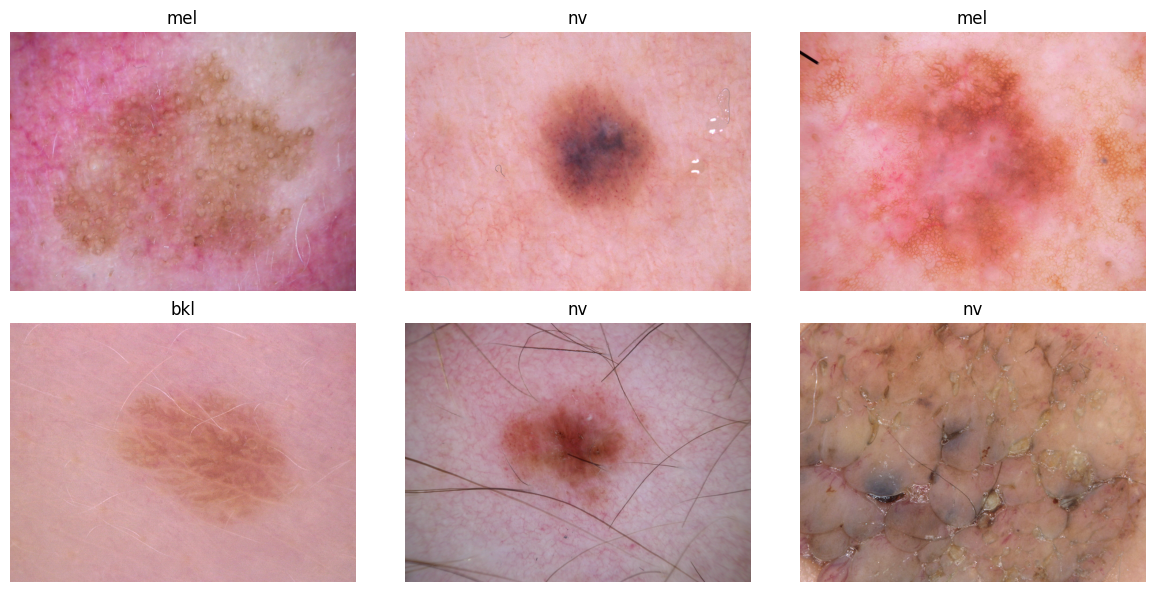

In [ ]:
# Load Metadata, Link Images, Sample Data, Visualize

import pandas as pd
import random
import matplotlib.pyplot as plt
from PIL import Image

# Define paths
base_path = "/kaggle/input/skin-cancer-mnist-ham10000"
img_dir_1 = os.path.join(base_path, "ham10000_images_part_1")
img_dir_2 = os.path.join(base_path, "ham10000_images_part_2")
meta_path = os.path.join(base_path, "HAM10000_metadata.csv")

# Load metadata
df = pd.read_csv(meta_path)

# Add image file paths
def get_image_path(img_id):
    filename = img_id + ".jpg"
    if os.path.exists(os.path.join(img_dir_1, filename)):
        return os.path.join(img_dir_1, filename)
    else:
        return os.path.join(img_dir_2, filename)

df['image_path'] = df['image_id'].apply(get_image_path)

# Subsample (10%)
df_sampled = df.sample(frac=0.10, random_state=42).reset_index(drop=True)

# Show a few samples
def show_examples(df, num=6):
    plt.figure(figsize=(12, 6))
    for i in range(num):
        path = df.iloc[i]['image_path']
        label = df.iloc[i]['dx']
        img = Image.open(path)
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(df_sampled)


In [ ]:
# Preprocessing and PyTorch Dataset Setup

import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Label encoding
label_mapping = {label: idx for idx, label in enumerate(df_sampled['dx'].unique())}
df_sampled['label'] = df_sampled['dx'].map(label_mapping)

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

dataset = SkinLesionDataset(df_sampled, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Check 1 batch shape
images, labels = next(iter(dataloader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [ ]:
# Train EfficientNet-B0 Classifier on HAM10000

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from tqdm import tqdm

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Replace classifier with new output layer
num_classes = len(label_mapping)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
epochs = 3  # Can change this if needed
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(dataloader):.4f}")

# Save model
torch.save(model.state_dict(), "efficientnet_ham10.pth")


Using device: cpu


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 32/32 [01:29<00:00,  2.80s/it]


Epoch 1, Loss: 1.6391


100%|██████████| 32/32 [01:21<00:00,  2.56s/it]


Epoch 2, Loss: 1.0187


100%|██████████| 32/32 [01:15<00:00,  2.36s/it]

Epoch 3, Loss: 0.7254


In [ ]:
# Feature Extraction from Trained EfficientNet-B0
# Extract Features for Mahalanobis

import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Rebuild EfficientNet-B0 and load weights
model = models.efficientnet_b0(pretrained=True)
num_classes = 7  # HAM10000 has 7 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load("efficientnet_ham10.pth", map_location=device))
model = model.to(device)
model.eval()

# Register hook on penultimate layer
feature_outputs = []

def hook(module, input, output):
    feature_outputs.append(output)

hook_handle = model.features.register_forward_hook(hook)

# Extract features from dataloader
labels_list = []
with torch.no_grad():
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        _ = model(images)  # triggers hook
        labels_list.append(labels)

# Remove the hook
hook_handle.remove()

# Convert to numpy
features = torch.cat(feature_outputs).cpu().numpy()
labels_all = torch.cat(labels_list).cpu().numpy()

print("Raw feature shape:", features.shape)
print("Label shape:", labels_all.shape)


Using device: cpu


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 32/32 [00:24<00:00,  1.29it/s]

Raw feature shape: (1002, 1280, 7, 7)
Label shape: (1002,)


In [ ]:
# PCA + Mahalanobis Stats

from sklearn.decomposition import PCA
from sklearn.covariance import EmpiricalCovariance

# Flatten if needed
if features.ndim == 4:
    n, c, h, w = features.shape
    features = features.reshape(n, c * h * w)
    print("Flattened feature shape:", features.shape)

# PCA to reduce dimensionality
n_components = 300
pca = PCA(n_components=n_components, whiten=True, random_state=42)
features_reduced = pca.fit_transform(features)

# Compute class means in PCA space
class_labels = np.unique(labels_all)
class_means = {
    cls: np.mean(features_reduced[labels_all == cls], axis=0)
    for cls in class_labels
}

# Fit covariance matrix
cov = EmpiricalCovariance().fit(features_reduced)
inv_cov = cov.precision_

print("PCA + Mahalanobis stats computed.")
print("Reduced feature shape:", features_reduced.shape)


Flattened feature shape: (1002, 62720)
PCA + Mahalanobis stats computed.
Reduced feature shape: (1002, 300)


In [ ]:
# Score All HAM Samples

# Mahalanobis distance function (vectorized for batch use)
def mahalanobis_distance(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(np.dot(np.dot(diff, inv_cov), diff.T))

# Score each sample by computing distance to true class mean
mahalanobis_scores = []

for x, label in zip(features_reduced, labels_all):
    mu = class_means[label]
    dist = mahalanobis_distance(x, mu, inv_cov)
    mahalanobis_scores.append(dist)

mahalanobis_scores = np.array(mahalanobis_scores)

# Show distribution summary
print("Mahalanobis distance stats (in-distribution):")
print(f"Min:  {mahalanobis_scores.min():.2f}")
print(f"Mean: {mahalanobis_scores.mean():.2f}")
print(f"Max:  {mahalanobis_scores.max():.2f}")

Mahalanobis distance stats (in-distribution):
Min:  3.65
Mean: 16.49
Max:  30.78


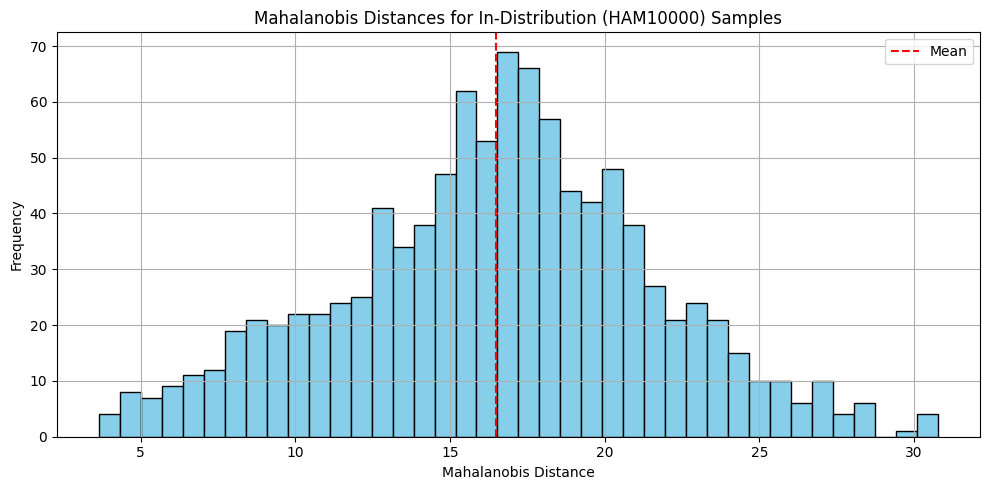

In [ ]:
# Plot Histogram of ID Mahalanobis Distances
# reference curve for ID dataset

# Plot histogram of Mahalanobis distances
plt.figure(figsize=(10, 5))
plt.hist(mahalanobis_scores, bins=40, color='skyblue', edgecolor='black')
plt.axvline(mahalanobis_scores.mean(), color='red', linestyle='--', label='Mean')
plt.title("Mahalanobis Distances for In-Distribution (HAM10000) Samples")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Load CIFAR-10 Datasets

from torchvision.datasets import CIFAR10

# Use same transform as HAM to match scale and distribution
ood_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Upsample to match EfficientNet input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Download CIFAR-10 test set
cifar_dataset = CIFAR10(root="./data", train=False, transform=ood_transform, download=True)

# Take a random 10% subsample
from torch.utils.data import Subset
import numpy as np

indices = np.random.choice(len(cifar_dataset), size=int(0.10 * len(cifar_dataset)), replace=False)
cifar_subset = Subset(cifar_dataset, indices)


100%|██████████| 170M/170M [00:10<00:00, 15.9MB/s]


In [ ]:
# passed CIFAR-10 images through trained EfficientNet
# Hooked and captured the penultimate features
# Flattened and projected them using the same PCA model from HAM10000
# Get cifar_features_reduced ready for Mahalanobis scoring


# Use your existing model + hook setup
model.eval()

# Reuse same feature hook
cifar_feature_outputs = []

def hook(module, input, output):
    cifar_feature_outputs.append(output)

hook_handle = model.features.register_forward_hook(hook)

# Run CIFAR-10 images through EfficientNet
from torch.utils.data import DataLoader

cifar_loader = DataLoader(cifar_subset, batch_size=32, shuffle=False)
cifar_labels = []  # not used for Mahalanobis, but can store if needed

with torch.no_grad():
    for images, labels in tqdm(cifar_loader):
        images = images.to(device)
        _ = model(images)
        cifar_labels.append(labels)

hook_handle.remove()

# Stack and preprocess CIFAR features
cifar_features = torch.cat(cifar_feature_outputs).cpu().numpy()

# Flatten if needed
if cifar_features.ndim == 4:
    n, c, h, w = cifar_features.shape
    cifar_features = cifar_features.reshape(n, c * h * w)

# PCA transform to match training space
cifar_features_reduced = pca.transform(cifar_features)


100%|██████████| 32/32 [00:13<00:00,  2.35it/s]


In [ ]:
# Compute Mahalanobis distances to all class means
# Score CIFAR Samples Using Mahalanobis Distance

cifar_scores = []

for x in cifar_features_reduced:
    # Measure distance to each class center
    distances = [mahalanobis_distance(x, mu, inv_cov) for mu in class_means.values()]
    min_dist = min(distances)  # closest class = best match
    cifar_scores.append(min_dist)

cifar_scores = np.array(cifar_scores)

# Summary
print("Mahalanobis distance stats (OOD - CIFAR):")
print(f"Min:  {cifar_scores.min():.2f}")
print(f"Mean: {cifar_scores.mean():.2f}")
print(f"Max:  {cifar_scores.max():.2f}")


Mahalanobis distance stats (OOD - CIFAR):
Min:  3.26
Mean: 6.81
Max:  216.99


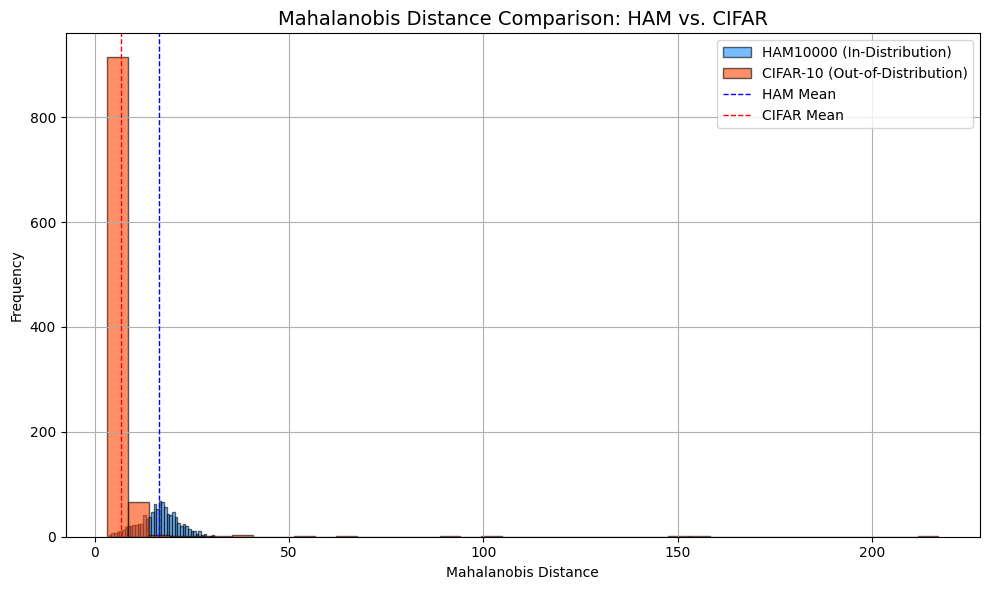

In [ ]:
# Plot HAM vs. CIFAR Mahalanobis Distances

plt.figure(figsize=(10, 6))

# In-distribution (HAM10000)
plt.hist(mahalanobis_scores, bins=40, alpha=0.6, color='dodgerblue', label='HAM10000 (In-Distribution)', edgecolor='black')

# Out-of-distribution (CIFAR-10)
plt.hist(cifar_scores, bins=40, alpha=0.6, color='orangered', label='CIFAR-10 (Out-of-Distribution)', edgecolor='black')

plt.axvline(mahalanobis_scores.mean(), color='blue', linestyle='--', linewidth=1, label='HAM Mean')
plt.axvline(cifar_scores.mean(), color='red', linestyle='--', linewidth=1, label='CIFAR Mean')

plt.title("Mahalanobis Distance Comparison: HAM vs. CIFAR", fontsize=14)
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
!pip install medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0
  Attempting uninstall: scipy
    Found existing installation: scipy 1.9.3
    Uninstalling scipy-1.9.3:
      Successfully uninstalled scipy-1.9.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-federated 0.87.0 requires scipy~=1.9.3, but you have scipy 1.15.2 which is incompatible.
tensorflow-federated 0.87.0 requires typing-extensions==4.5.*,>=4.5.0, but you have typing-extensions 4.13.2 which is incompatible.
langchain-co

In [ ]:
# Prepare Medmnist

from medmnist import INFO
from medmnist.dataset import PathMNIST
from torch.utils.data import DataLoader


# Metadata
info = INFO['pathmnist']
DataClass = PathMNIST

# Transform (normalize to [-1, 1] range)
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x - 0.5) / 0.5)
])

# Load full dataset
train_dataset = DataClass(split='train', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)  # [32, 3, 28, 28] or [32, 9, 28, 28]
print("Label batch shape:", labels.shape)  # [32]

Image batch shape: torch.Size([32, 3, 28, 28])
Label batch shape: torch.Size([32, 1])


In [ ]:
# Subsample from medmnist
from torch.utils.data import Subset

np.random.seed(42)
subset_indices = np.random.choice(len(train_dataset), size=1000, replace=False)
train_dataset_sub = Subset(train_dataset, subset_indices)

train_loader = DataLoader(train_dataset_sub, batch_size=32, shuffle=False)


In [ ]:
import torchvision.models as models
import torch.nn as nn

# Load pre-trained EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Send to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Hook setup
feature_outputs = []

def hook(module, input, output):
    feature_outputs.append(output)

# Register on the penultimate layer
hook_handle = model.features.register_forward_hook(hook)

# Extract features
labels_list = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        _ = model(images)
        labels_list.append(labels)

# Remove hook
hook_handle.remove()

# Stack outputs
import torch

features = torch.cat(feature_outputs).cpu()
labels_all = torch.cat(labels_list).cpu().numpy()

print("Raw features shape:", features.shape)
print("Label array shape:", labels_all.shape)


Raw features shape: torch.Size([1000, 1280, 1, 1])
Label array shape: (1000, 1)


In [ ]:
features.shape  # before flattening


torch.Size([1000, 1280, 1, 1])

In [ ]:
# Flatten to [1000, 1280]
features = features.view(features.size(0), -1)
print("Flattened features shape:", features.shape)


Flattened features shape: torch.Size([1000, 1280])


In [ ]:
from sklearn.decomposition import PCA

# Refit PCA using the current flattened HAM features
# features should be shape [1000, 1280] from HAM10000
pca = PCA(n_components=300, whiten=True, random_state=42)
features_reduced = pca.fit_transform(features.numpy())  # Refit PCA

print("Refit PCA on HAM features.")
print("Projected PCA shape:", features_reduced.shape)



Refit PCA on HAM features.
Projected PCA shape: (1000, 300)


In [ ]:
# Mahalanobis score
pathmnist_scores = []

for x in features_reduced:
    distances = [mahalanobis_distance(x, mu, inv_cov) for mu in class_means.values()]
    min_dist = min(distances)
    pathmnist_scores.append(min_dist)

pathmnist_scores = np.array(pathmnist_scores)

# Summary stats
print("Mahalanobis distance stats (OOD - PathMNIST):")
print(f"Min:  {pathmnist_scores.min():.2f}")
print(f"Mean: {pathmnist_scores.mean():.2f}")
print(f"Max:  {pathmnist_scores.max():.2f}")


Mahalanobis distance stats (OOD - PathMNIST):
Min:  5.53
Mean: 15.80
Max:  31.52


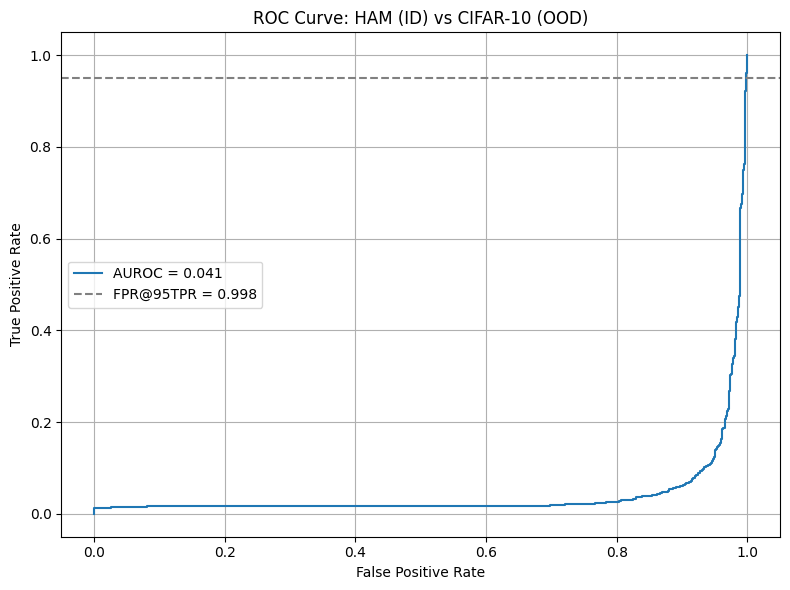

In [ ]:
# HAM (ID) vs CIFAR-10 (OOD)

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

# Prepare labels
y_true = np.concatenate([
    np.zeros_like(mahalanobis_scores),  # HAM = in-distribution = 0
    np.ones_like(cifar_scores)          # CIFAR = OOD = 1
])

# Concatenate Mahalanobis scores
y_scores = np.concatenate([mahalanobis_scores, cifar_scores])

# Compute metrics
fpr, tpr, _ = roc_curve(y_true, y_scores)
auroc = roc_auc_score(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
auprc = auc(recall, precision)

# FPR@95% TPR
fpr_at_95_tpr = fpr[np.searchsorted(tpr, 0.95)]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.axhline(0.95, color='gray', linestyle='--', label=f"FPR@95TPR = {fpr_at_95_tpr:.3f}")
plt.title("ROC Curve: HAM (ID) vs CIFAR-10 (OOD)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

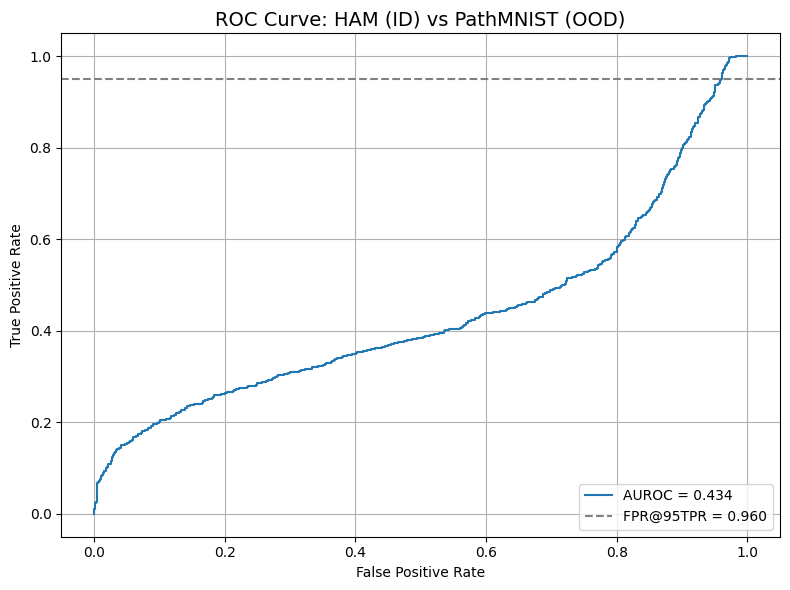

In [ ]:
# ROC Curve: HAM (ID) vs PathMNIST (OOD)

# Prepare labels
y_true = np.concatenate([
    np.zeros_like(mahalanobis_scores),     # HAM = in-distribution = 0
    np.ones_like(pathmnist_scores)         # PathMNIST = OOD = 1
])

# Combine Mahalanobis scores
y_scores = np.concatenate([
    mahalanobis_scores,
    pathmnist_scores
])

# Compute metrics
fpr, tpr, _ = roc_curve(y_true, y_scores)
auroc = roc_auc_score(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
auprc = auc(recall, precision)

# FPR@95%TPR
try:
    fpr_at_95_tpr = fpr[np.searchsorted(tpr, 0.95)]
except IndexError:
    fpr_at_95_tpr = 1.0  # fallback if TPR never reaches 0.95

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.axhline(0.95, color='gray', linestyle='--', label=f"FPR@95TPR = {fpr_at_95_tpr:.3f}")
plt.title("ROC Curve: HAM (ID) vs PathMNIST (OOD)", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Re-hook for Gram matrix extraction
gram_features = []

def gram_hook(module, input, output):
    gram_features.append(output)

# Register at deeper layer
hook_handle = model.features[6].register_forward_hook(gram_hook)

# Extract features from HAM dataloader
with torch.no_grad():
    for images, _ in tqdm(dataloader):
        images = images.to(device)
        _ = model(images)

hook_handle.remove()

# Stack all features
ham_activations = torch.cat(gram_features, dim=0).cpu()

# Compute Gram matrices
def compute_gram_matrix(tensor):
    B, C, H, W = tensor.shape
    tensor = tensor.view(B, C, H * W)
    gram = torch.bmm(tensor, tensor.transpose(1, 2))  # shape: [B, C, C]
    return gram

ham_gram_matrices = compute_gram_matrix(ham_activations)
ham_gram_flat = ham_gram_matrices.view(ham_gram_matrices.size(0), -1).numpy()
ham_gram_mean = ham_gram_flat.mean(axis=0)

print("HAM Gram shape:", ham_gram_flat.shape)
print("Mean Gram vector shape:", ham_gram_mean.shape)

100%|██████████| 32/32 [00:27<00:00,  1.17it/s]

HAM Gram shape: (2004, 36864)
Mean Gram vector shape: (36864,)


In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

# Distance to mean Gram vector
ham_gram_scores = euclidean_distances(
    ham_gram_flat, ham_gram_mean.reshape(1, -1)
).flatten()

print("HAM Gram Scores:")
print(f"Min:  {ham_gram_scores.min():.2f}")
print(f"Mean: {ham_gram_scores.mean():.2f}")
print(f"Max:  {ham_gram_scores.max():.2f}")

HAM Gram Scores:
Min:  39804.04
Mean: 67729.85
Max:  184641.52


In [ ]:
# Reset Gram features
gram_features = []

# Hook setup
def gram_hook(module, input, output):
    gram_features.append(output)

hook_handle = model.features[6].register_forward_hook(gram_hook)

# Extract features
with torch.no_grad():
    for images, _ in tqdm(cifar_loader):
        images = images.to(device)
        _ = model(images)

hook_handle.remove()

# Stack + Compute Gram
cifar_activations = torch.cat(gram_features, dim=0).cpu()
cifar_gram_matrices = compute_gram_matrix(cifar_activations)
cifar_gram_flat = cifar_gram_matrices.view(cifar_gram_matrices.size(0), -1).numpy()

# Euclidean Distance to HAM mean
cifar_gram_scores = euclidean_distances(cifar_gram_flat, ham_gram_mean.reshape(1, -1)).flatten()

# Output shapes and stats
print("CIFAR-10 Gram shape:", cifar_gram_flat.shape)
print("Mean Gram vector shape (HAM):", ham_gram_mean.shape)
print(f"CIFAR-10 Gram Scores:\nMin:  {cifar_gram_scores.min():.2f}\nMean: {cifar_gram_scores.mean():.2f}\nMax:  {cifar_gram_scores.max():.2f}")


100%|██████████| 32/32 [00:13<00:00,  2.40it/s]


CIFAR-10 Gram shape: (2000, 36864)
Mean Gram vector shape (HAM): (36864,)
CIFAR-10 Gram Scores:
Min:  71443.68
Mean: 104751.52
Max:  253854.38


In [ ]:
# Reset Gram features
gram_features = []

# Hook setup
def gram_hook(module, input, output):
    gram_features.append(output)

hook_handle = model.features[6].register_forward_hook(gram_hook)

# Extract features
with torch.no_grad():
    for images, _ in tqdm(train_loader):
        images = images.to(device)
        _ = model(images)

hook_handle.remove()

# Compute Gram
path_activations = torch.cat(gram_features, dim=0).cpu()
path_gram_matrices = compute_gram_matrix(path_activations)
path_gram_flat = path_gram_matrices.view(path_gram_matrices.size(0), -1).numpy()

# Euclidean Distance to HAM mean
from sklearn.metrics.pairwise import euclidean_distances
path_gram_scores = euclidean_distances(path_gram_flat, ham_gram_mean.reshape(1, -1)).flatten()

# Output shapes and stats
print("PathMNIST Gram shape:", path_gram_flat.shape)
print("Mean Gram vector shape (HAM):", ham_gram_mean.shape)
print(f"PathMNIST Gram Scores:\nMin:  {path_gram_scores.min():.2f}\nMean: {path_gram_scores.mean():.2f}\nMax:  {path_gram_scores.max():.2f}")


100%|██████████| 32/32 [00:02<00:00, 12.51it/s]


PathMNIST Gram shape: (2000, 36864)
Mean Gram vector shape (HAM): (36864,)
PathMNIST Gram Scores:
Min:  52890.95
Mean: 53401.78
Max:  54160.04


In [ ]:
!git clone https://github.com/TalwalkarLab/leaf.git


Cloning into 'leaf'...
remote: Enumerating objects: 782, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 782 (delta 1), reused 2 (delta 0), pack-reused 776 (from 1)
Receiving objects: 100% (782/782), 6.78 MiB | 15.47 MiB/s, done.
Resolving deltas: 100% (372/372), done.


In [ ]:
%cd leaf/data/femnist


/content/FLamby/leaf/data/femnist/leaf/data/femnist


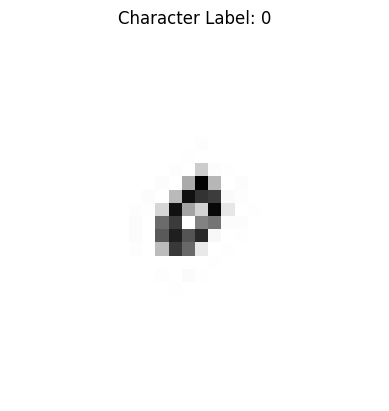

In [ ]:
from datasets import load_dataset

# Load FEMNIST dataset
dataset = load_dataset("flwrlabs/femnist")

# visualize
sample = dataset['train'][0]
image = sample['image']
label = sample['character']

plt.imshow(image, cmap='gray')
plt.title(f"Character Label: {label}")
plt.axis('off')
plt.show()


In [ ]:
from collections import defaultdict

client_data = defaultdict(list)
subset = dataset['train'].select(range(20000))  # Only use 20,000 samples

for sample in subset:
    writer = sample['writer_id']
    client_data[writer].append(sample)

print(f"Subset clients: {len(client_data)}")

Subset clients: 56


In [ ]:
# Pick a few clients with enough data (200+)
selected_clients = [cid for cid, data in client_data.items() if len(data) >= 200][:3]

for cid in selected_clients:
    print(f"Client {cid}: {len(client_data[cid])} samples")

Client f0000_14: 382 samples
Client f0001_41: 413 samples
Client f0002_01: 404 samples


In [ ]:
# Prepare Each Client’s Data for Model Training
import numpy as np

def preprocess_client_data(samples):
    images = [np.array(s['image']) / 255.0 for s in samples]  # normalize pixel values
    labels = [s['character'] for s in samples]
    X = np.stack(images).reshape(-1, 28, 28, 1)  # add channel dimension
    y = np.array(labels)
    return X, y

# Example: preprocess data for client 0
client_0_data = client_data[selected_clients[0]]
X0, y0 = preprocess_client_data(client_0_data)

print("Client 0 - X shape:", X0.shape)
print("Client 0 - y shape:", y0.shape)

Client 0 - X shape: (382, 28, 28, 1)
Client 0 - y shape: (382,)


In [ ]:
# Build & Train a Small CNN for Each Client
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, kernel_size=3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(62, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
from sklearn.model_selection import train_test_split

# Train/val split for client 0
X0_train, X0_val, y0_train, y0_val = train_test_split(X0, y0, test_size=0.2, random_state=42)

# Build and train model
model_0 = create_model()
model_0.fit(X0_train, y0_train, epochs=5, validation_data=(X0_val, y0_val), verbose=2)

Epoch 1/5
10/10 - 1s - loss: 4.0250 - accuracy: 0.0492 - val_loss: 3.9289 - val_accuracy: 0.0519 - 1s/epoch - 140ms/step
Epoch 2/5
10/10 - 0s - loss: 3.8163 - accuracy: 0.0885 - val_loss: 3.8395 - val_accuracy: 0.0519 - 155ms/epoch - 16ms/step
Epoch 3/5
10/10 - 0s - loss: 3.6928 - accuracy: 0.0885 - val_loss: 3.8210 - val_accuracy: 0.0519 - 155ms/epoch - 15ms/step
Epoch 4/5
10/10 - 0s - loss: 3.6256 - accuracy: 0.0885 - val_loss: 3.8096 - val_accuracy: 0.0519 - 159ms/epoch - 16ms/step
Epoch 5/5
10/10 - 0s - loss: 3.5908 - accuracy: 0.1246 - val_loss: 3.7843 - val_accuracy: 0.0519 - 149ms/epoch - 15ms/step


In [ ]:
# Accuracy bad from above but not needed
# Create feature extractor
feature_extractor = tf.keras.Model(
    inputs=model_0.input,
    outputs=model_0.layers[-2].output
)

In [ ]:
# Get embeddings for in-distribution data (client 0 train set)
X0_embed = feature_extractor.predict(X0_train)
print("Embedding shape:", X0_embed.shape)

10/10 [==============================] - 0s 4ms/step
Embedding shape: (305, 128)


In [ ]:
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv

# Compute mean and covariance of embeddings
mu = np.mean(X0_embed, axis=0)
cov = np.cov(X0_embed, rowvar=False)
inv_cov = inv(cov + 1e-5 * np.eye(cov.shape[0]))

print("Mean vector shape:", mu.shape)

Mean vector shape: (128,)


In [ ]:
# Prepare data for another client (e.g., client 1)
client_1_data = client_data[selected_clients[1]]
X1, y1 = preprocess_client_data(client_1_data)

# Get embeddings using same feature extractor
X1_embed = feature_extractor.predict(X1)
print("Client 1 embedding shape:", X1_embed.shape)

13/13 [==============================] - 0s 5ms/step
Client 1 embedding shape: (413, 128)


In [ ]:
# Function to compute Mahalanobis distances
def compute_mahalanobis_scores(embeddings, mu, inv_cov):
    return [mahalanobis(x, mu, inv_cov) for x in embeddings]

# Scores
scores_in = compute_mahalanobis_scores(X0_embed, mu, inv_cov)  # Client 0
scores_ood = compute_mahalanobis_scores(X1_embed, mu, inv_cov)  # Client 1

# Combine scores and labels
all_scores = np.array(scores_in + scores_ood)
all_labels = np.array([0] * len(scores_in) + [1] * len(scores_ood))  # 0 = in-dist, 1 = OOD

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# AUROC
auroc = roc_auc_score(all_labels, all_scores)
print("AUROC:", round(auroc * 100, 2))

# FPR@95 TPR
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
fpr95 = fpr[np.where(tpr >= 0.95)[0][0]] if np.any(tpr >= 0.95) else 1.0
print("FPR@95TPR:", round(fpr95 * 100, 2))

AUROC: 54.87
FPR@95TPR: 87.54


In [ ]:
# Client 1 (retrain)
# Prepare data
client_1_data = client_data[selected_clients[1]]
X1, y1 = preprocess_client_data(client_1_data)
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Train
model_1 = create_model()
model_1.fit(X1_train, y1_train, epochs=5, validation_data=(X1_val, y1_val), verbose=2)

Epoch 1/5
11/11 - 1s - loss: 4.0320 - accuracy: 0.0333 - val_loss: 3.8293 - val_accuracy: 0.0602 - 1s/epoch - 117ms/step
Epoch 2/5
11/11 - 0s - loss: 3.8282 - accuracy: 0.0424 - val_loss: 3.7388 - val_accuracy: 0.0602 - 176ms/epoch - 16ms/step
Epoch 3/5
11/11 - 0s - loss: 3.7160 - accuracy: 0.0455 - val_loss: 3.6564 - val_accuracy: 0.0602 - 158ms/epoch - 14ms/step
Epoch 4/5
11/11 - 0s - loss: 3.6411 - accuracy: 0.0606 - val_loss: 3.6580 - val_accuracy: 0.0964 - 208ms/epoch - 19ms/step
Epoch 5/5
11/11 - 0s - loss: 3.5938 - accuracy: 0.0727 - val_loss: 3.6220 - val_accuracy: 0.0843 - 240ms/epoch - 22ms/step


In [ ]:
# Client 2
# Prepare data
client_2_data = client_data[selected_clients[2]]
X2, y2 = preprocess_client_data(client_2_data)
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train
model_2 = create_model()
model_2.fit(X2_train, y2_train, epochs=5, validation_data=(X2_val, y2_val), verbose=2)

Epoch 1/5
11/11 - 1s - loss: 4.0247 - accuracy: 0.0248 - val_loss: 3.7853 - val_accuracy: 0.0988 - 1s/epoch - 106ms/step
Epoch 2/5
11/11 - 0s - loss: 3.7849 - accuracy: 0.0836 - val_loss: 3.8374 - val_accuracy: 0.0617 - 152ms/epoch - 14ms/step
Epoch 3/5
11/11 - 0s - loss: 3.7286 - accuracy: 0.0960 - val_loss: 3.9026 - val_accuracy: 0.0617 - 144ms/epoch - 13ms/step
Epoch 4/5
11/11 - 0s - loss: 3.6541 - accuracy: 0.0960 - val_loss: 3.8357 - val_accuracy: 0.0617 - 148ms/epoch - 13ms/step
Epoch 5/5
11/11 - 0s - loss: 3.6406 - accuracy: 0.0681 - val_loss: 3.7444 - val_accuracy: 0.1235 - 148ms/epoch - 13ms/step


In [ ]:
# Get model weights
weights_0 = model_0.get_weights()
weights_1 = model_1.get_weights()
weights_2 = model_2.get_weights()

# Average the weights layer by layer
avg_weights = [(w0 + w1 + w2) / 3 for w0, w1, w2 in zip(weights_0, weights_1, weights_2)]

In [ ]:
# Create a new model and assign averaged weights
global_model = create_model()
global_model.set_weights(avg_weights)

In [ ]:
# Extract features from penultimate layer for Mahalanobis
global_feature_extractor = tf.keras.Model(
    inputs=global_model.input,
    outputs=global_model.layers[-2].output
)

In [ ]:
# Reuse preprocessed data from Client 0
X0_embed_global = global_feature_extractor.predict(X0_train)

10/10 [==============================] - 0s 4ms/step


In [ ]:
# Recalculate Mahalanobis stats using global model embeddings
mu_global = np.mean(X0_embed_global, axis=0)
cov_global = np.cov(X0_embed_global, rowvar=False)
inv_cov_global = inv(cov_global + 1e-5 * np.eye(cov_global.shape[0]))

In [ ]:
# Pick an new client for OOD evaluation
unseen_client = [cid for cid in client_data if cid not in selected_clients and len(client_data[cid]) >= 200][0]
print("Unseen client ID:", unseen_client)

X_ood, y_ood = preprocess_client_data(client_data[unseen_client])
X_ood_embed = global_feature_extractor.predict(X_ood)

Unseen client ID: f0003_42
13/13 [==============================] - 0s 4ms/step


In [ ]:
# Compute Mahalanobis scores
scores_in = compute_mahalanobis_scores(X0_embed_global, mu_global, inv_cov_global)
scores_ood = compute_mahalanobis_scores(X_ood_embed, mu_global, inv_cov_global)

# Labels: 0 = ID, 1 = OOD
all_scores = np.array(scores_in + scores_ood)
all_labels = np.array([0] * len(scores_in) + [1] * len(scores_ood))

# AUROC and FPR@95TPR
auroc = roc_auc_score(all_labels, all_scores)
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
fpr95 = fpr[np.where(tpr >= 0.95)[0][0]] if np.any(tpr >= 0.95) else 1.0

print("AUROC (FedAvg):", round(auroc * 100, 2))
print("FPR@95TPR (FedAvg):", round(fpr95 * 100, 2))

AUROC (FedAvg): 71.92
FPR@95TPR (FedAvg): 79.67


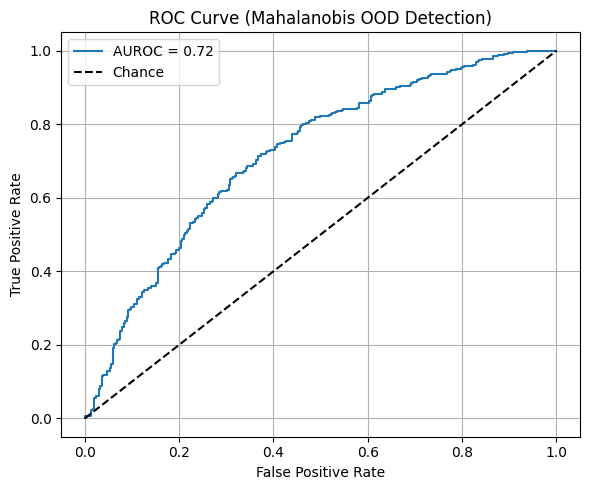

In [ ]:
# ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUROC = {auroc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Mahalanobis OOD Detection)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def compute_gram_vector(embedding):
    gram = np.outer(embedding, embedding)
    return gram[np.triu_indices_from(gram)]

In [ ]:
# Compute Gram vectors
grams_id = np.array([compute_gram_vector(x) for x in X0_embed_global])
grams_ood = np.array([compute_gram_vector(x) for x in X_ood_embed])

In [ ]:
# Compute mean Gram vector from ID
gram_mu = grams_id.mean(axis=0)

# Euclidean distance to the mean gram vector
scores_id_gram = np.linalg.norm(grams_id - gram_mu, axis=1)
scores_ood_gram = np.linalg.norm(grams_ood - gram_mu, axis=1)

# Combine
all_scores_gram = np.concatenate([scores_id_gram, scores_ood_gram])
all_labels_gram = np.array([0] * len(scores_id_gram) + [1] * len(scores_ood_gram))

In [ ]:
# Eval
auroc_gram = roc_auc_score(all_labels_gram, all_scores_gram)
fpr_g, tpr_g, thresholds_g = roc_curve(all_labels_gram, all_scores_gram)
fpr95_gram = fpr_g[np.where(tpr_g >= 0.95)[0][0]] if np.any(tpr_g >= 0.95) else 1.0

print("AUROC (Gram):", round(auroc_gram * 100, 2))
print("FPR@95TPR (Gram):", round(fpr95_gram * 100, 2))

AUROC (Gram): 81.3
FPR@95TPR (Gram): 61.64


In [ ]:
# create simulated clients from HAM10000

# Choose 3 lesion types
client_groups = {
    'nv': df_sampled[df_sampled['dx'] == 'nv'].sample(100, random_state=1),
    'bkl': df_sampled[df_sampled['dx'] == 'bkl'].sample(100, random_state=2),
    'mel': df_sampled[df_sampled['dx'] == 'mel'].sample(100, random_state=3),
}
client_ids = list(client_groups.keys())

In [ ]:
def load_client_data(df, size=(64, 64)):
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = Image.open(row['image_path']).resize(size).convert('RGB')
            images.append(np.array(img) / 255.0)
            labels.append(row['dx'])
        except:
            continue
    return np.array(images), np.array(labels)

In [ ]:
X_clients, y_clients = {}, {}

for cid in client_ids:
    X, y = load_client_data(client_groups[cid])
    X_clients[cid] = X
    y_clients[cid] = y
    print(f"{cid}: X shape = {X.shape}, y shape = {y.shape}")

nv: X shape = (100, 64, 64, 3), y shape = (100,)
bkl: X shape = (100, 64, 64, 3), y shape = (100,)
mel: X shape = (100, 64, 64, 3), y shape = (100,)


In [ ]:
# Define the CNN

import tensorflow as tf
from tensorflow.keras import layers, models

def create_model():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')  # 3 classes: nv, bkl, mel
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
label_map = {'nv': 0, 'bkl': 1, 'mel': 2}
for cid in client_ids:
    y_clients[cid] = np.array([label_map[y] for y in y_clients[cid]])

In [ ]:
from sklearn.model_selection import train_test_split

client_models = {}

for cid in client_ids:
    X_train, X_val, y_train, y_val = train_test_split(
        X_clients[cid], y_clients[cid], test_size=0.2, random_state=42)

    model = create_model()
    print(f"Training model for client: {cid}")
    model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=2)
    client_models[cid] = model

Training model for client: nv
Epoch 1/5
3/3 - 1s - loss: 0.4683 - accuracy: 0.7750 - val_loss: 5.8129e-05 - val_accuracy: 1.0000 - 1s/epoch - 446ms/step
Epoch 2/5
3/3 - 0s - loss: 2.6766e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000 - 186ms/epoch - 62ms/step
Epoch 3/5
3/3 - 0s - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000 - 251ms/epoch - 84ms/step
Epoch 4/5
3/3 - 0s - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000 - 188ms/epoch - 63ms/step
Epoch 5/5
3/3 - 0s - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000 - 158ms/epoch - 53ms/step
Training model for client: bkl
Epoch 1/5
3/3 - 1s - loss: 0.4443 - accuracy: 0.6000 - val_loss: 7.3314e-07 - val_accuracy: 1.0000 - 1s/epoch - 393ms/step
Epoch 2/5
3/3 - 0s - loss: 1.8626e-07 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000 - 156ms/epoch - 52ms/step
Epoch 3/5
3/3 - 0s - loss: 0.0000e+00 - accuracy

In [ ]:
# Extract weights
weights = [client_models[cid].get_weights() for cid in client_ids]

# Avg weights across all models
avg_weights = [np.mean(layer_weights, axis=0) for layer_weights in zip(*weights)]

In [ ]:
# Create new model and load the averaged weights
global_model = create_model()
global_model.set_weights(avg_weights)

In [ ]:
# Extract layer outputs for Mahalanobis/Gram
global_feature_extractor = tf.keras.Model(
    inputs=global_model.input,
    outputs=global_model.layers[-2].output
)

In [ ]:
X_id = X_clients['nv']  # ID
X_id_embed = global_feature_extractor.predict(X_id)

4/4 [==============================] - 0s 13ms/step


In [ ]:
# Pick unseen lesion type (not like clients)
ood_type = 'vasc'  # or try 'df', 'akiec', etc.

df_ood = df_sampled[df_sampled['dx'] == ood_type]
X_ood, _ = load_client_data(df_ood)

X_ood_embed = global_feature_extractor.predict(X_ood)

1/1 [==============================] - 0s 30ms/step


In [ ]:
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv

# Fit Mahalanobis on ID embeddings
mu = np.mean(X_id_embed, axis=0)
cov = np.cov(X_id_embed, rowvar=False)
inv_cov = inv(cov + 1e-5 * np.eye(cov.shape[0]))

# Mahalanobis distances
def compute_mahalanobis_scores(embeddings, mu, inv_cov):
    return [mahalanobis(x, mu, inv_cov) for x in embeddings]

scores_id = compute_mahalanobis_scores(X_id_embed, mu, inv_cov)
scores_ood = compute_mahalanobis_scores(X_ood_embed, mu, inv_cov)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

all_scores = np.array(scores_id + scores_ood)
all_labels = np.array([0] * len(scores_id) + [1] * len(scores_ood))

auroc = roc_auc_score(all_labels, all_scores)
fpr, tpr, _ = roc_curve(all_labels, all_scores)
fpr95 = fpr[np.where(tpr >= 0.95)[0][0]] if np.any(tpr >= 0.95) else 1.0

print("AUROC:", round(auroc * 100, 2))
print("FPR@95TPR:", round(fpr95 * 100, 2))

AUROC: 62.0
FPR@95TPR: 96.0


In [ ]:
# Hello